In [18]:
#感知机（不是线性向量机）
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["SimHei"],  # 黑体
    "axes.unicode_minus": False
})
#生成数据集
X,y=make_classification(
    n_samples=100,
    n_features=2,#两个特征
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

y=np.where(y==0,-1,1)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

class Perceptron:
    def __init__(self,learning_rate=0.1,max_iter=100):
        self.lr=learning_rate #学习率
        self.max_iter=max_iter#最大迭代次数
        self.w=None
        self.b=0
    
    def fit(self,X,y):
        n_samples,n_features=X.shape
        self.w=np.zeros(n_features)#矩阵初始化为0
        self.b=0

        #迭代更新
        for _ in range(self.max_iter):
            update=False
            for idx,x_i in enumerate(X):
                #分类错误更新
                if y[idx]*(np.dot(x_i,self.w)+self.b)<=0:
                    self.w+=self.lr*y[idx]*x_i
                    self.b+=self.lr*y[idx]
                    update=True
                if not update:
                    break
    def predict(self,X):
        return np.sign(np.dot(X,self.w)+self.b)

In [19]:
model=Perceptron(learning_rate=0.1,max_iter=100)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(f"test accuracy:{accuracy_score(y_test,y_pred):.2f}")
print(f"weight w:{np.round(model.w,4)}")
print(f"bisa: b:{model.b}")



test accuracy:1.00
weight w:[-0.1736  0.2536]
bisa: b:0.1


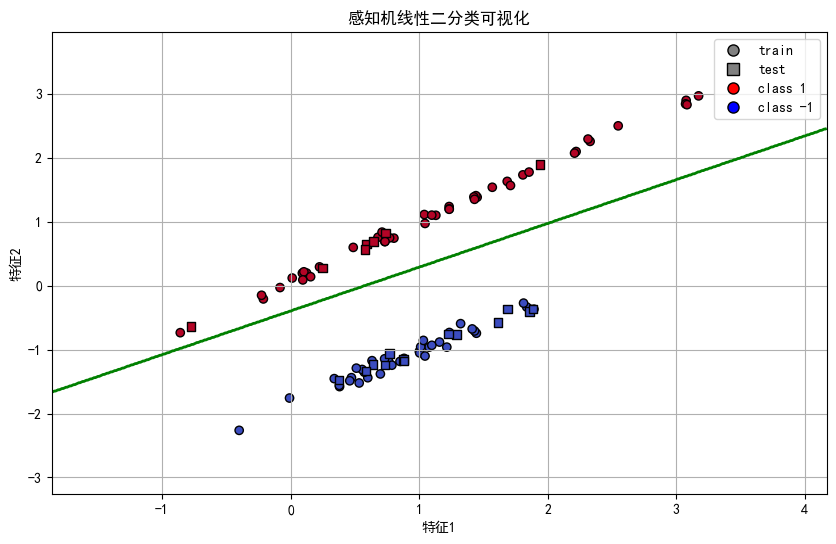

In [21]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='coolwarm',edgecolors='k',label='train')#冷暖来区别是否正确，形状是区别训练集和测试集合
plt.scatter(X_test[:,0],X_test[:,1],c=y_test,cmap='coolwarm',marker='s',edgecolors='k',label='test')
x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
y_min,y_max=X[:,1].min()-1,X[:,1].max()+1
xx,yy=np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))
Z=model.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
plt.contour(xx,yy,Z,colors='green',linewidths=2,levels=[0])
plt.xlabel('特征1')
plt.ylabel('特征2')
plt.title('感知机线性二分类可视化')
custom_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='train'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markeredgecolor='k', markersize=8, label='test'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markeredgecolor='k', markersize=8, label='class 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='k', markersize=8, label='class -1')
]
plt.legend(handles=custom_legend, loc='upper right')
plt.grid(True)
plt.show()